# Extract time series of precipitation from CombiPrecip

In [2]:
#%conda list
#%pip install rioxarray

In [3]:
from pyproj import Proj, Transformer, transform, CRS
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import xesmf as xe
import matplotlib.patches as mpatches
import glob
import os
import pandas as pd
### Save raster file
import rioxarray
import re

In [18]:
### MAIN FOLDER
dir_main='/Users/edolores/Documents/UBERN/Collaborations/Vollmer/rainfall_scenarios'

### Parameters
#Extent: CRS: EPSG:2056 - CH1903+ / LV95 - Projected
### Old Extent: 2573533.0309730102308095,1130168.0344431323464960 : 2583366.5957598802633584,1136653.6297571107279509

#New Extent: 2578332.3470160271972418,1130067.1025373837910593 : 2583349.2409602385014296,1133713.7435100483708084
## I considero that:
min_x,min_y=2578332.3470160271972418,1130067.1025373837910593
max_x,max_y=2583349.2409602385014296,1133713.7435100483708084

### center point
x_center = 0.5 * (min_x + max_x)
y_center = 0.5 * (min_y + max_y)

#Buffer to the right to cover full domain
deltax=1000
max_x+=deltax

#Projection: EPSG 2056 - CH 1903+ / LV95
#Date= 24.06.2005 (Julian day of 24 June 2005 is: 175)
#Time: 14.30 to 20.00
year='2005'
month='06'
day='24'
hour0='14:30'
hourn='20:00'

width_size = max_x -min_x
height_size =max_y -min_y
print(width_size,height_size)

6016.893944211304 3646.6409726645797


## Helpers

In [6]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def rates_to_depths_mm(time_s, rate_mps):
    """
    Assumes rate[i] applies on interval [time[i], time[i+1]).
    Returns interval depths in mm and interval start/end times.
    """
    time_s = np.asarray(time_s, dtype=float)
    rate_mps = np.asarray(rate_mps, dtype=float)

    dt = np.diff(time_s)                  # seconds
    interval_rates = rate_mps[:-1]        # one value per interval
    depth_mm = interval_rates * dt * 1000.0

    return depth_mm, time_s[:-1], time_s[1:]

def normalized_mass_curve(time_s, rate_mps):
    depth_mm, t0, t1 = rates_to_depths_mm(time_s, rate_mps)
    total = depth_mm.sum()

    if total <= 0:
        raise ValueError("Total rainfall is zero.")

    frac = depth_mm / total
    cum = np.concatenate([[0.0], np.cumsum(frac)])  # length = n_intervals + 1

    # normalized time from 0 to 1
    t_norm = (time_s - time_s[0]) / (time_s[-1] - time_s[0])

    return t_norm, cum

def resample_mass_curve_to_duration(t_norm, cum_frac, duration_s, dt_s=300):
    """
    Returns interval rainfall fractions for a storm of duration_s with timestep dt_s.
    """
    n_steps = int(duration_s // dt_s)
    new_time = np.arange(0, n_steps + 1) * dt_s
    new_t_norm = new_time / duration_s

    f = interp1d(t_norm, cum_frac, kind="linear", bounds_error=False,
                 fill_value=(0.0, 1.0))
    new_cum = f(new_t_norm)

    interval_frac = np.diff(new_cum)

    # numerical cleanup
    interval_frac = np.maximum(interval_frac, 0.0)
    interval_frac = interval_frac / interval_frac.sum()

    return new_time, interval_frac

def fractions_to_model_rates(total_mm, interval_frac, dt_s=300):
    depth_mm = total_mm * interval_frac
    rate_mps = depth_mm / 1000.0 / dt_s
    return rate_mps

def triangular_fractions_1h(dt_s=300):
    if dt_s != 300:
        raise ValueError("This simple version assumes 5-minute steps (300 s).")

    weights = np.array([1, 3, 5, 7, 9, 11, 11, 9, 7, 5, 3, 1], dtype=float)
    return weights / weights.sum()

def wetting_trigger_fractions(duration_s, dt_s=300, wet_fraction=0.7, trigger_fraction=0.3,
                              trigger_part=0.25):
    """
    duration_s: total storm duration
    wet_fraction + trigger_fraction should sum to 1
    trigger_part: fraction of duration assigned to trigger phase
                  e.g. 0.25 means final 25% of event is trigger
    """
    n_steps = int(duration_s // dt_s)
    n_trigger = max(1, int(round(n_steps * trigger_part)))
    n_wet = n_steps - n_trigger

    if n_wet < 1:
        raise ValueError("Trigger part too long for duration.")

    # constant wetting phase
    wet = np.ones(n_wet, dtype=float)
    wet = wet / wet.sum() * wet_fraction

    # triangular trigger phase
    if n_trigger == 1:
        trigger = np.array([trigger_fraction])
    else:
        x = np.arange(n_trigger)
        center = (n_trigger - 1) / 2.0
        tri = 1.0 - np.abs(x - center) / max(center, 1e-12)
        tri = np.maximum(tri, 1e-6)
        trigger = tri / tri.sum() * trigger_fraction

    frac = np.concatenate([wet, trigger])
    frac = frac / frac.sum()

    time_s = np.arange(0, n_steps + 1) * dt_s
    return time_s, frac

def plot_rainfall_comparison(
    marcela_time,
    marcela_rate,
    scenario_time,
    scenario_rate,
    title="Rainfall comparison",
    show_ms=False
):
    """
    Compare observed (Marcela) rainfall and scenario rainfall.

    Parameters
    ----------
    marcela_time : array (s)
    marcela_rate : array (m/s)

    scenario_time : array (s)
    scenario_rate : array (m/s)

    show_ms : bool
        If True also plot rates in m/s.
    """

    # convert to hours
    marcela_time_h = np.array(marcela_time) / 3600
    scenario_time_h = np.array(scenario_time) / 3600

    # convert to mm/h for easier interpretation
    marcela_mmh = np.array(marcela_rate) * 1000 * 3600
    scenario_mmh = np.array(scenario_rate) * 1000 * 3600

    fig, ax = plt.subplots(figsize=(8,5))

    ax.step(marcela_time_h, marcela_mmh, where="post",
            label="Observed (Marcela)", linewidth=2)

    ax.step(scenario_time_h[:-1], scenario_mmh, where="post",
            label="Scenario", linewidth=2)

    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Rainfall intensity (mm/h)")
    ax.set_title(title)

    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # optional second plot in m/s
    if show_ms:

        fig, ax = plt.subplots(figsize=(8,5))

        ax.step(marcela_time_h, marcela_rate, where="post",
                label="Observed (Marcela)", linewidth=2)

        ax.step(scenario_time_h[:-1], scenario_rate, where="post",
                label="Scenario", linewidth=2)

        ax.set_xlabel("Time (hours)")
        ax.set_ylabel("Rainfall rate (m/s)")
        ax.set_title(title + " (model units)")

        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()

## Explore the former data

Text(0, 0.5, 'Precipitation (m/s)')

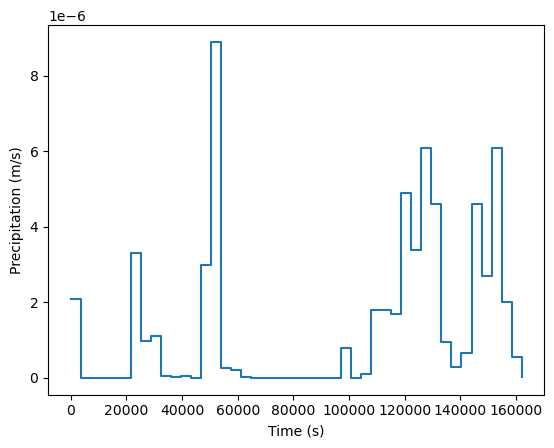

In [7]:
#Original precipitation in m/s as input to EDDA (Ping values)
#s = "your raw numbers here"
#arr = [float(x) for x in re.split(r'[,\s]+', s) if x]

# 46 values (cri)
precip = [
2.1E-06, 0.0E+00, 0.0E+00, 0.0E+00, 0.0E+00, 0.0E+00, 3.3E-06, 9.7E-07,
1.1E-06, 5.6E-08, 2.8E-08, 5.6E-08, 0.0E+00, 3.0E-06, 8.9E-06, 2.5E-07,
2.2E-07, 2.8E-08, 0.0E+00, 0.0E+00, 0.0E+00, 0.0E+00, 0.0E+00, 0.0E+00,
0.0E+00, 0.0E+00, 0.0E+00, 7.8E-07, 0.0E+00, 1.1E-07, 1.8E-06, 1.8E-06,
1.7E-06, 4.9E-06, 3.4E-06, 6.1E-06, 4.6E-06, 9.4E-07, 2.8E-07, 6.7E-07,
4.6E-06, 2.7E-06, 6.1E-06, 2.0E-06, 5.6E-07, 2.8E-08
]

# 47 values (capt)
time = [
0, 3600, 7200, 10800, 14400, 18000, 21600, 25200, 28800, 32400, 36000,
39600, 43200, 46800, 50400, 54000, 57600, 61200, 64800, 68400, 72000,
75600, 79200, 82800, 86400, 90000, 93600, 97200, 100800, 104400, 108000,
111600, 115200, 118800, 122400, 126000, 129600, 133200, 136800, 140400,
144000, 147600, 151200, 154800, 158400, 162000, 165600
]

# As array
precip = np.array(precip)
time = np.array(time)

time_mid = 0.5 * (time[:-1] + time[1:]) # midpoint time of each interval

#plt.plot(time_mid, precip)
plt.step(time[:-1], precip, where="post")
plt.xlabel("Time (s)")
plt.ylabel("Precipitation (m/s)")

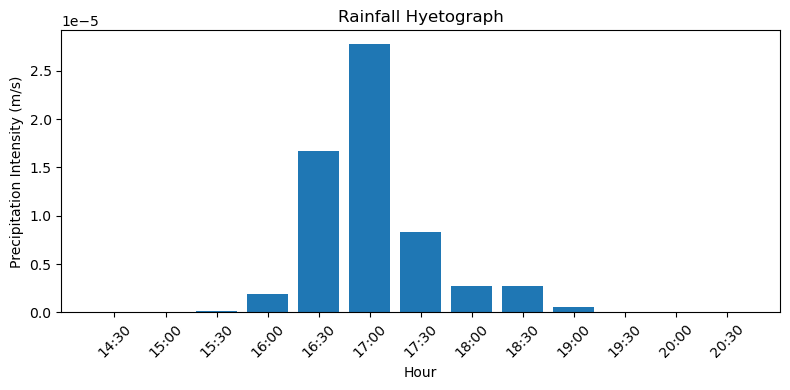

In [8]:
### Marcela input to model calibration
hour = [
"14:30", "15:00", "15:30", "16:00", "16:30", "17:00",
"17:30", "18:00", "18:30", "19:00", "19:30", "20:00", "20:30"
]
time = [
0, 1800, 3600, 5400, 7200, 9000,
10800, 12600, 14400, 16200, 18000, 19800, 21600
]
precip = [
0.0, 8.3334E-08, 1.94446E-07, 1.94446E-06, 1.66668E-05,
2.7778E-05, 8.3334E-06, 2.7778E-06, 2.7778E-06,
5.5556E-07, 8.3334E-08, 0.0, 0.0
]

#plt.plot(time, precip)

#plt.step(hour, precip, where="post") #time[:-1], precip, where="post")
#plt.xlabel("Time (s)")
#plt.ylabel("Precipitation (m/s)")

plt.figure(figsize=(8,4))
plt.bar(hour, precip)

plt.xlabel("Hour")
plt.ylabel("Precipitation Intensity (m/s)")
plt.title("Rainfall Hyetograph")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

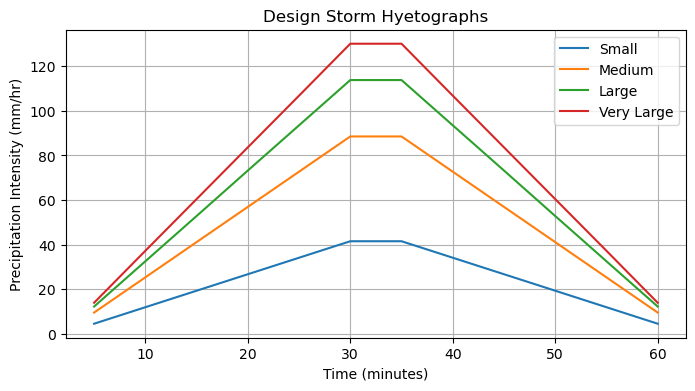

In [9]:
### scenarios precipitation (Fischer)
minutes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
small = [
4.5, 11.9, 19.3, 26.7, 34.1, 41.5,
41.5, 34.1, 26.7, 19.3, 11.9, 4.5
]
small_avg = 23.0

medium = [
9.5, 25.3, 41.1, 56.9, 72.7, 88.5,
88.5, 72.7, 56.9, 41.1, 25.3, 9.5
]
medium_avg = 49.0

large = [
12.2, 32.5, 52.8, 73.2, 93.5, 113.8,
113.8, 93.5, 73.2, 52.8, 32.5, 12.2
]
large_avg = 63.0

very_large = [
13.9, 37.2, 60.4, 83.6, 106.8, 130.1,
130.1, 106.8, 83.6, 60.4, 37.2, 13.9
]
very_large_avg = 72.0

plt.figure(figsize=(8,4))

plt.plot(minutes, small, label="Small")
plt.plot(minutes, medium, label="Medium")
plt.plot(minutes, large, label="Large")
plt.plot(minutes, very_large, label="Very Large")

plt.xlabel("Time (minutes)")
plt.ylabel("Precipitation Intensity (mm/hr)")
plt.title("Design Storm Hyetographs")

plt.legend()
plt.grid(True)

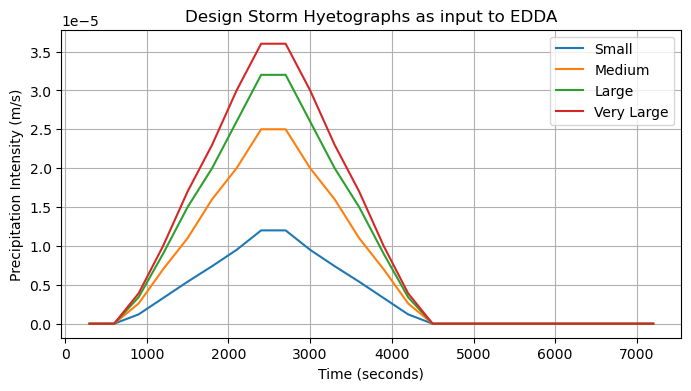

In [10]:
### Using those scenarios for debris flow modelling
time = [
300, 600, 900, 1200, 1500, 1800, 2100, 2400,
2700, 3000, 3300, 3600, 3900, 4200, 4500, 4800,
5100, 5400, 5700, 6000, 6300, 6600, 6900, 7200
]
small = [
0, 0, 1.2E-06, 3.3E-06, 5.4E-06, 7.4E-06,
9.5E-06, 1.2E-05, 1.2E-05, 9.5E-06, 7.4E-06,
5.4E-06, 3.3E-06, 1.2E-06, 0, 0, 0, 0,
0, 0, 0, 0, 0, 0
]
small_avg = 6.4E-06

medium = [
0, 0, 2.6E-06, 7.0E-06, 1.1E-05, 1.6E-05,
2.0E-05, 2.5E-05, 2.5E-05, 2.0E-05, 1.6E-05,
1.1E-05, 7.0E-06, 2.6E-06, 0, 0, 0, 0,
0, 0, 0, 0, 0, 0
]
medium_avg = 1.4E-05

large = [
0, 0, 3.4E-06, 9.0E-06, 1.5E-05, 2.0E-05,
2.6E-05, 3.2E-05, 3.2E-05, 2.6E-05, 2.0E-05,
1.5E-05, 9.0E-06, 3.4E-06, 0, 0, 0, 0,
0, 0, 0, 0, 0, 0
]
large_avg = 1.8E-05

very_large = [
0, 0, 3.9E-06, 1.0E-05, 1.7E-05, 2.3E-05,
3.0E-05, 3.6E-05, 3.6E-05, 3.0E-05, 2.3E-05,
1.7E-05, 1.0E-05, 3.9E-06, 0, 0, 0, 0,
0, 0, 0, 0, 0, 0
]
very_large_avg = 2.0E-05

plt.figure(figsize=(8,4))

plt.plot(time, small, label="Small")
plt.plot(time, medium, label="Medium")
plt.plot(time, large, label="Large")
plt.plot(time, very_large, label="Very Large")

plt.xlabel("Time (seconds)")
plt.ylabel("Precipitation Intensity (m/s)")
plt.title("Design Storm Hyetographs as input to EDDA")

plt.legend()
plt.grid(True)

In [11]:
### Test to build the scenarios
minutes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
weights = [1, 3, 5, 7, 9, 11, 11, 9, 7, 5, 3, 1]

def thunderstorm_scenario(total_rain_mm):
    # 5-minute rainfall amounts (mm per 5 min)
    rain_5min = [total_rain_mm * w / sum(weights) for w in weights]

    # intensities in mm/h
    intensity = [r * 12 for r in rain_5min]

    # average intensity over the hour
    avg_intensity = sum(intensity) / len(intensity)

    return intensity, avg_intensity

# scenarios
small, small_avg = thunderstorm_scenario(23)
medium, medium_avg = thunderstorm_scenario(49)
large, large_avg = thunderstorm_scenario(63)
very_large, very_large_avg = thunderstorm_scenario(72)

print("small =", [round(x, 1) for x in small], "avg =", round(small_avg, 1))
print("medium =", [round(x, 1) for x in medium], "avg =", round(medium_avg, 1))
print("large =", [round(x, 1) for x in large], "avg =", round(large_avg, 1))
print("very_large =", [round(x, 1) for x in very_large], "avg =", round(very_large_avg, 1))

small = [3.8, 11.5, 19.2, 26.8, 34.5, 42.2, 42.2, 34.5, 26.8, 19.2, 11.5, 3.8] avg = 23.0
medium = [8.2, 24.5, 40.8, 57.2, 73.5, 89.8, 89.8, 73.5, 57.2, 40.8, 24.5, 8.2] avg = 49.0
large = [10.5, 31.5, 52.5, 73.5, 94.5, 115.5, 115.5, 94.5, 73.5, 52.5, 31.5, 10.5] avg = 63.0
very_large = [12.0, 36.0, 60.0, 84.0, 108.0, 132.0, 132.0, 108.0, 84.0, 60.0, 36.0, 12.0] avg = 72.0


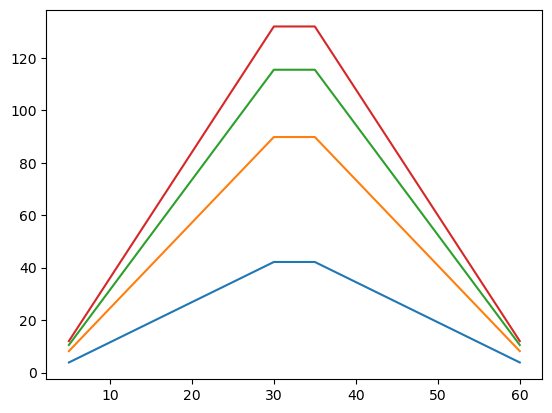

In [12]:
plt.plot(minutes, small, label="Small")
plt.plot(minutes, medium, label="Medium")
plt.plot(minutes, large, label="Large")
plt.plot(minutes, very_large, label="Very Large")

In [19]:
### Let's open HADES data
R1h=xr.open_dataset(dir_main+'/data/climate-precipitation-maps-returnperiod-data_60-minute-sum.nc', 
decode_times=False
)
print(R1h)

<xarray.Dataset> Size: 11MB
Dimensions:                 (dummy: 1, time: 1, ncb: 2, probability: 3, N: 265,
                             E: 370)
Coordinates:
  * dummy                   (dummy) float64 8B 1.0
  * time                    (time) float64 8B 0.0
  * ncb                     (ncb) float64 16B 1.0 2.0
  * probability             (probability) float64 24B 0.025 0.5 0.975
  * N                       (N) float64 2kB 1.06e+06 1.06e+06 ... 1.324e+06
  * E                       (E) float64 3kB 2.474e+06 2.476e+06 ... 2.844e+06
    lon                     (N, E) float32 392kB ...
    lat                     (N, E) float32 392kB ...
Data variables:
    swiss_lv95_coordinates  (dummy) float64 8B ...
    climatology_bounds      (time, ncb) float64 16B ...
    X2                      (time, probability, N, E) float32 1MB ...
    X5                      (time, probability, N, E) float32 1MB ...
    X10                     (time, probability, N, E) float32 1MB ...
    X20                 

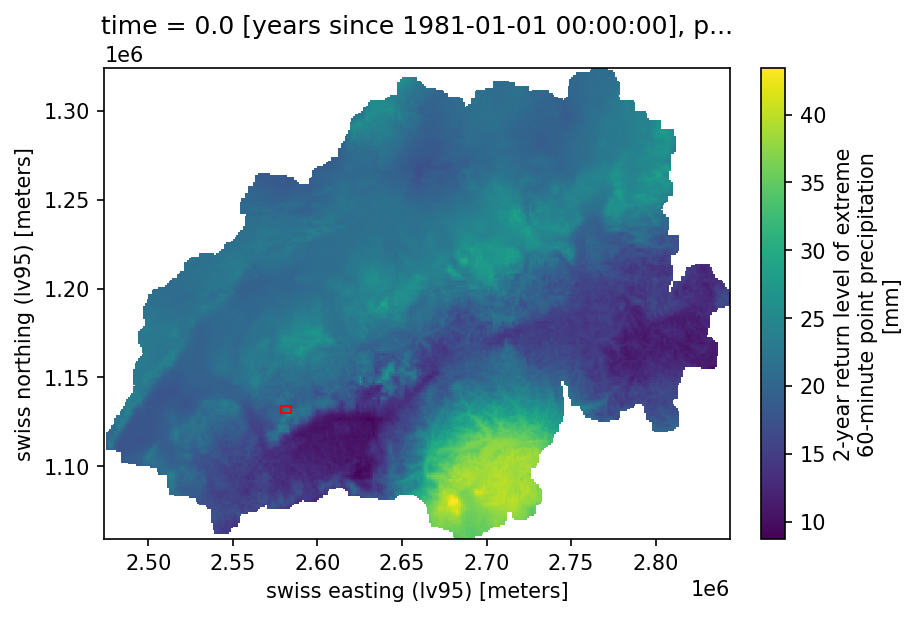

In [27]:
#R1h['X2'].sel(probability=0.095).squeeze().plot()
#R1h['X2'].sel(probability=0.5).squeeze().plot()

### plot: area of interest
plt.figure(figsize=(6,4),dpi=150,layout='constrained')
ax=plt.axes()
R1h['X2'].sel(probability=0.5).squeeze().plot(ax=ax)
ax.add_patch(mpatches.Rectangle(xy=[min_x, min_y], width=width_size, height=height_size, \
        facecolor='none', alpha=0.95, edgecolor='r', linewidth=1, zorder=1))

In [ ]:
### select one point (center)
#R1h['X2'].sel(probability=0.975)
R1h_2 = R1h['X2'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
R1h_30 = R1h['X30'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
R1h_100 = R1h['X100'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
R1h_200 = R1h['X200'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
print(R1h_2, R1h_30, R1h_100, R1h_200)

20.83028 43.748898 55.80187 63.865597


In [41]:
### select region and compute mean
region=R1h['X2'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=0.5).mean().values# inverse order for coordinate y
print(region)
#region.max().values

21.193909


## Marcela-shaped scenarios 

In [35]:
#1 h Marcela-shaped
#3 h Marcela-shaped
#12 h Marcela-shaped

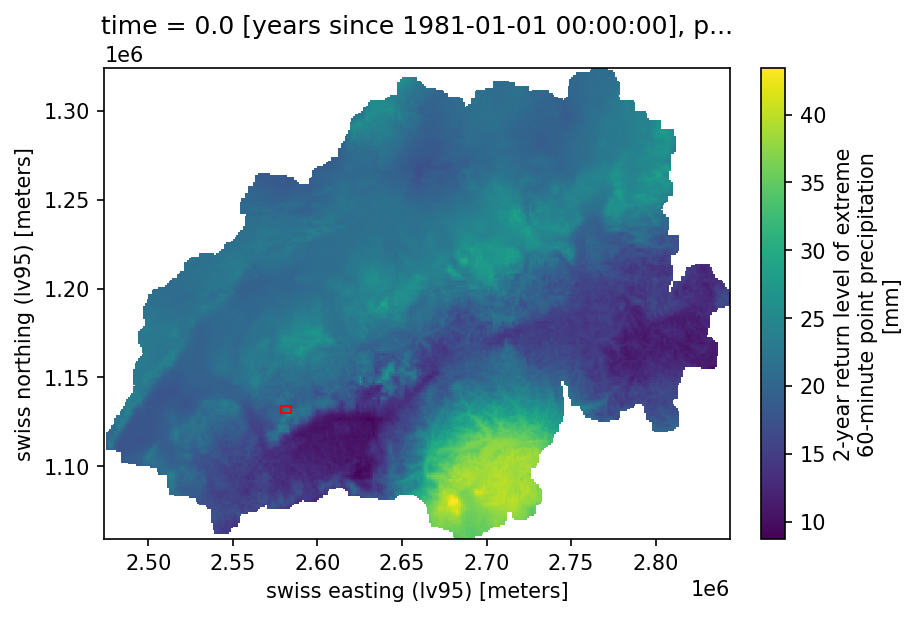

In [ ]:
### Let's open HADES data
R1h=xr.open_dataset(dir_main+'/data/climate-precipitation-maps-returnperiod-data_60-minute-sum.nc', decode_times=False)
R3h=xr.open_dataset(dir_main+'/data/climate-precipitation-maps-returnperiod-data_180-minute-sum.nc', decode_times=False)
R6h=xr.open_dataset(dir_main+'/data/climate-precipitation-maps-returnperiod-data_6-hour-sum.nc', decode_times=False)
R12h=xr.open_dataset(dir_main+'/data/climate-precipitation-maps-returnperiod-data_12-hour-sum.nc', decode_times=False)

### plot: area of interest
plt.figure(figsize=(6,4),dpi=150,layout='constrained')
ax=plt.axes()
R1h['X2'].sel(probability=0.5).squeeze().plot(ax=ax)
ax.add_patch(mpatches.Rectangle(xy=[min_x, min_y], width=width_size, height=height_size, \
        facecolor='none', alpha=0.95, edgecolor='r', linewidth=1, zorder=1))

### select one point
#R1h_2 = R1h['X2'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#R1h_30 = R1h['X30'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#R1h_100 = R1h['X100'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#R1h_200 = R1h['X200'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#print(R1h_2, R1h_30, R1h_100, R1h_200)
#R3h_2 = R3h['X2'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#R3h_30 = R3h['X30'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#R3h_100 = R3h['X100'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#R3h_200 = R3h['X200'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#print(R3h_2, R3h_30, R3h_100, R3h_200)
#R6h_2 = R6h['X2'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#R6h_30 = R6h['X30'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#R6h_100 = R6h['X100'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#R6h_200 = R6h['X200'].sel(N=y_center, E=x_center, probability=0.5, method="nearest").squeeze().values #min_x,min_y
#print(R6h_2, R6h_30, R6h_100, R6h_200)

In [128]:
### select region and compute mean
prob=0.975 #0.025 0.5 0.975
R1h_2 = R1h['X2'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R1h_30 = R1h['X30'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R1h_100 = R1h['X100'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R1h_200 = R1h['X200'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R1h_300 = R1h['X300'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
print(R1h_2, R1h_30, R1h_100, R1h_200, R1h_300)
R3h_2 = R3h['X2'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R3h_30 = R3h['X30'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R3h_100 = R3h['X100'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R3h_200 = R3h['X200'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R3h_300 = R3h['X300'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
print(R3h_2, R3h_30, R3h_100, R3h_200, R3h_300)
R6h_2 = R6h['X2'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R6h_30 = R6h['X30'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R6h_100 = R6h['X100'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R6h_200 = R6h['X200'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
R6h_300 = R6h['X300'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).mean().values
print(R6h_2, R6h_30, R6h_100, R6h_200, R6h_300)

25.585093 60.941895 80.94262 94.169334 102.83844
34.557858 64.31834 80.54722 90.97204 97.53977
48.679703 86.19901 105.95615 118.744385 127.11143


In [114]:
### select region and compute max
R1h_2 = R1h['X2'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R1h_30 = R1h['X30'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R1h_100 = R1h['X100'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R1h_200 = R1h['X200'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R1h_300 = R1h['X300'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
print(R1h_2, R1h_30, R1h_100, R1h_200, R1h_300)
R3h_2 = R3h['X2'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R3h_30 = R3h['X30'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R3h_100 = R3h['X100'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R3h_200 = R3h['X200'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R3h_300 = R3h['X300'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
print(R3h_2, R3h_30, R3h_100, R3h_200, R3h_300)
R6h_2 = R6h['X2'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R6h_30 = R6h['X30'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R6h_100 = R6h['X100'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R6h_200 = R6h['X200'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
R6h_300 = R6h['X300'].sel(N=slice(min_y,max_y), E=slice(min_x, max_x),probability=prob).max().values
print(R6h_2, R6h_30, R6h_100, R6h_200, R6h_300)

24.371943 52.272552 66.973335 76.787834 82.8991
35.677822 58.424664 68.785835 75.36512 79.348335
51.419357 82.83233 97.047646 105.369675 110.2491


In [215]:
### Step 1: define your Marcela event
marcela_time = np.array([
    0, 1800, 3600, 5400, 7200, 9000,
    10800, 12600, 14400, 16200, 18000, 19800, 21600
], dtype=float)

marcela_rate = np.array([
    0.0, 8.3334E-08, 1.94446E-07, 1.94446E-06, 1.66668E-05,
    2.7778E-05, 8.3334E-06, 2.7778E-06, 2.7778E-06,
    5.5556E-07, 8.3334E-08, 0.0, 0.0
], dtype=float)

#Step 2: get normalized Marcela mass curve
t_norm, cum_frac = normalized_mass_curve(marcela_time, marcela_rate)


#Step 3: define HADES totals
###pointwise (central point)
#hades_totals = {
#    "1h":  {2: 20.83028, 30: 43.748898, 100: 55.80187, 200: 63.865597},
#    "3h":  {2: 31.122324, 30: 52.04475, 100: 61.713867 , 200: 67.69967},
#    "6h": {2: 44.466087, 30: 72.14302, 100: 84.11422, 200: 91.27356},
#}
### Area mean (0.500)
hades_totals = {
    "1h":  {2: 21.193909, 30:  44.814167, 100:  57.48058, 200:  65.81278, 300: 71.03678},
    "3h":  {2: 31.182251, 30:  52.618946, 100:  62.62549, 200:  68.78928, 300: 72.50448},
    "6h": {2: 44.33868, 30:  72.28124, 100:  84.70498, 200:  92.170494, 300: 96.61417},
}
### Area mean (0.975)
#hades_totals = {
#    "1h":  {2: 25.585093, 30:  60.941895, 100:  80.94262, 200:  94.169334, 300: 102.83844},
#    "3h":  {2: 34.557858, 30:  64.31834, 100:  80.54722, 200:  90.97204 , 300: 97.53977},
#    "6h": {2: 48.679703, 30:  86.19901, 100:  105.95615, 200:  118.744385, 300: 127.11143},
#}
#Area max
#hades_totals = {
#    "1h":  {2: 24.371943, 30:  52.272552, 100:   66.973335, 200:  76.787834, 300:  82.8991},
#    "3h":  {2: 35.677822, 30:  58.424664, 100:  68.785835, 200:  75.36512, 300: 79.348335 },
#    "6h": {2: 51.419357, 30:   82.83233, 100:  97.047646, 200:  105.369675, 300:110.2491},
#}

#Step 4: build one Marcela-shaped scenario
dur_hh = 6 # 1= 1 hour, 3 = 3 hours, 6 = 6 hours,
re_per = 200 # 2, 30, 100, 200, 300
duration_s = dur_hh * 3600 
dt_s = 300

time_s, frac = resample_mass_curve_to_duration(t_norm, cum_frac, duration_s, dt_s=dt_s)
###rate_mps = fractions_to_model_rates(hades_totals["1h"][30], frac, dt_s=dt_s)
rate_mps = fractions_to_model_rates(hades_totals[str(dur_hh)+"h"][re_per], frac, dt_s=dt_s)

### output saving
#np.savetxt(dir_main+"/output/rainfall_scenario_"+str(dur_hh)+"h_"+str(re_per)+"years_0500P.csv",rate_mps, delimiter=",")
#np.savetxt(dir_main+"/output/rainfall_scenario_"+str(dur_hh)+"h_"+str(re_per)+"years_0975P.csv",rate_mps, delimiter=",")

total_mm = np.sum(rate_mps * dt_s * 1000.0)
rate_mmh = rate_mps * 1000.0 * 3600.0
print(total_mm)
print(np.all(rate_mps >= 0))
print(time_s[-1]) # Duration is correct?? (3600 for 1 h, 3600 for 1 h, 14400 for 4 h)
print(rate_mmh)

#plt.plot(rate_mps)  ### Plot all scenarios 

92.170494
True
21600
[ 0.          0.          0.          0.          0.          0.
  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176
  0.58574077  0.58574077  0.58574077  0.58574077  0.58574077  0.58574077
  5.8574077   5.8574077   5.8574077   5.8574077   5.8574077   5.8574077
 50.2063517  50.2063517  50.2063517  50.2063517  50.2063517  50.2063517
 83.67725284 83.67725284 83.67725284 83.67725284 83.67725284 83.67725284
 25.10317585 25.10317585 25.10317585 25.10317585 25.10317585 25.10317585
  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528
  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528
  1.67354506  1.67354506  1.67354506  1.67354506  1.67354506  1.67354506
  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176
  0.          0.          0.          0.          0.          0.        ]


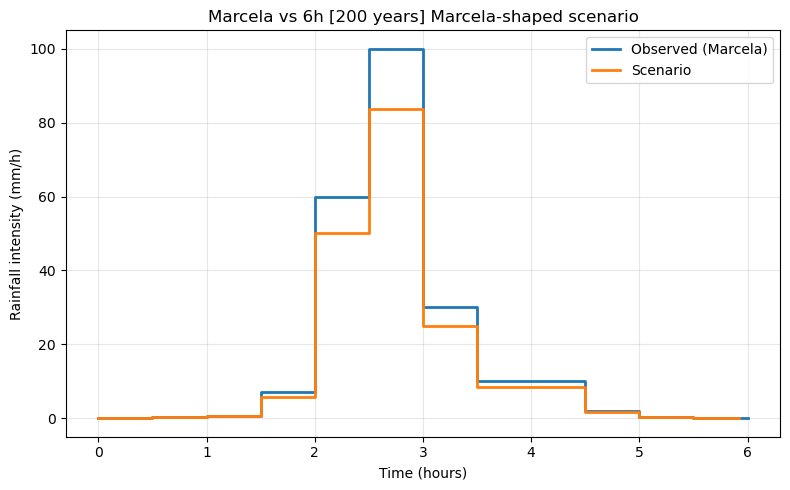

In [216]:
scenario_time = time_s
scenario_rate = rate_mps
plot_rainfall_comparison(
    marcela_time,
    marcela_rate,
    scenario_time,
    scenario_rate,
    title="Marcela vs "+str(dur_hh)+"h ["+str(re_per)+" years] Marcela-shaped scenario"
)

### Build one triangular 1 h scenario (Fischer)

92.170494
True
21600
[ 0.          0.          0.          0.          0.          0.
  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176
  0.58574077  0.58574077  0.58574077  0.58574077  0.58574077  0.58574077
  5.8574077   5.8574077   5.8574077   5.8574077   5.8574077   5.8574077
 50.2063517  50.2063517  50.2063517  50.2063517  50.2063517  50.2063517
 83.67725284 83.67725284 83.67725284 83.67725284 83.67725284 83.67725284
 25.10317585 25.10317585 25.10317585 25.10317585 25.10317585 25.10317585
  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528
  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528
  1.67354506  1.67354506  1.67354506  1.67354506  1.67354506  1.67354506
  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176
  0.          0.          0.          0.          0.          0.        ]


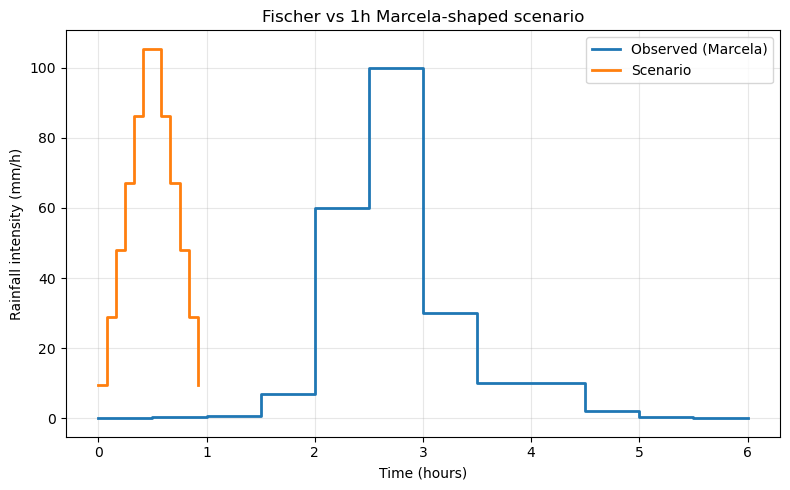

In [65]:

frac_tri = triangular_fractions_1h(dt_s=300)
time_tri = np.arange(0, 3600 + 300, 300)
rate_tri = fractions_to_model_rates(hades_totals["1h"][100], frac_tri, dt_s=300)

total_mm = np.sum(rate_mps * dt_s * 1000.0)
rate_mmh = rate_mps * 1000.0 * 3600.0
print(total_mm)
print(np.all(rate_mps >= 0))
print(time_s[-1])
print(rate_mmh)

scenario_time = time_tri
scenario_rate = rate_tri
plot_rainfall_comparison(
    marcela_time,
    marcela_rate,
    scenario_time,
    scenario_rate,
    title="Fischer vs 1h Marcela-shaped scenario"
)

### Antecedent wetting + trigger (family 3)

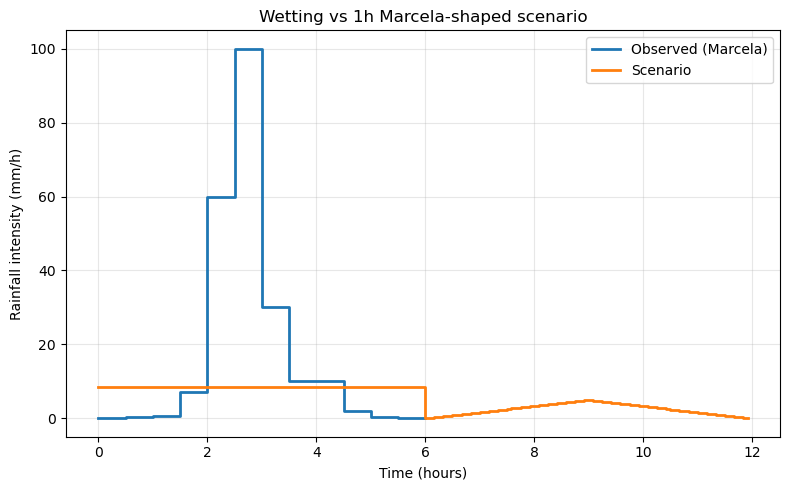

In [79]:
# 12 h pre-wetting + 1 h trigger
#Step 6: build one wetting-trigger scenario
time_wt, frac_wt = wetting_trigger_fractions(
    duration_s=12*3600,
    dt_s=300,
    wet_fraction=0.7,
    trigger_fraction=0.2,
    trigger_part=6/12   # last 6 h of a 12 h event
)

rate_wt = fractions_to_model_rates(hades_totals["1h"][200], frac_wt, dt_s=300)

scenario_time = time_wt
scenario_rate = rate_wt
plot_rainfall_comparison(
    marcela_time,
    marcela_rate,
    scenario_time,
    scenario_rate,
    title="Wetting vs 1h Marcela-shaped scenario"
)

## Climate change - Scaling precipitation intensity

In [217]:
### Step 1: define your Marcela event
marcela_time = np.array([
    0, 1800, 3600, 5400, 7200, 9000,
    10800, 12600, 14400, 16200, 18000, 19800, 21600
], dtype=float)

marcela_rate = np.array([
    0.0, 8.3334E-08, 1.94446E-07, 1.94446E-06, 1.66668E-05,
    2.7778E-05, 8.3334E-06, 2.7778E-06, 2.7778E-06,
    5.5556E-07, 8.3334E-08, 0.0, 0.0
], dtype=float)

#Step 2: get normalized Marcela mass curve
t_norm, cum_frac = normalized_mass_curve(marcela_time, marcela_rate)


#Step 3: define HADES totals
### Area mean (0.500)
hades_totals = {
    "1h":  {2: 21.193909, 30:  44.814167, 100:  57.48058, 200:  65.81278, 300: 71.03678},
    "3h":  {2: 31.182251, 30:  52.618946, 100:  62.62549, 200:  68.78928, 300: 72.50448},
    "6h": {2: 44.33868, 30:  72.28124, 100:  84.70498, 200:  92.170494, 300: 96.61417},
}
### Area mean (0.975)
#hades_totals = {
#    "1h":  {2: 25.585093, 30:  60.941895, 100:  80.94262, 200:  94.169334, 300: 102.83844},
#    "3h":  {2: 34.557858, 30:  64.31834, 100:  80.54722, 200:  90.97204 , 300: 97.53977},
#    "6h": {2: 48.679703, 30:  86.19901, 100:  105.95615, 200:  118.744385, 300: 127.11143},
#}


#Step 4: build one Marcela-shaped scenario
dur_hh = 6 # 1= 1 hour, 3 = 3 hours, 6 = 6 hours,
re_per = 200 # 2, 30, 100, 200, 300
duration_s = dur_hh * 3600 
dt_s = 300

time_s, frac = resample_mass_curve_to_duration(t_norm, cum_frac, duration_s, dt_s=dt_s)
###rate_mps = fractions_to_model_rates(hades_totals["1h"][30], frac, dt_s=dt_s)
rate_mps = fractions_to_model_rates(hades_totals[str(dur_hh)+"h"][re_per], frac, dt_s=dt_s)

total_mm = np.sum(rate_mps * dt_s * 1000.0)
rate_mmh = rate_mps * 1000.0 * 3600.0
print(total_mm)
print(np.all(rate_mps >= 0))
print(time_s[-1]) # Duration is correct?? (3600 for 1 h, 3600 for 1 h, 14400 for 4 h)
print(rate_mmh)

#plt.plot(rate_mps)  ### Plot all scenarios 

92.170494
True
21600
[ 0.          0.          0.          0.          0.          0.
  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176
  0.58574077  0.58574077  0.58574077  0.58574077  0.58574077  0.58574077
  5.8574077   5.8574077   5.8574077   5.8574077   5.8574077   5.8574077
 50.2063517  50.2063517  50.2063517  50.2063517  50.2063517  50.2063517
 83.67725284 83.67725284 83.67725284 83.67725284 83.67725284 83.67725284
 25.10317585 25.10317585 25.10317585 25.10317585 25.10317585 25.10317585
  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528
  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528  8.36772528
  1.67354506  1.67354506  1.67354506  1.67354506  1.67354506  1.67354506
  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176  0.25103176
  0.          0.          0.          0.          0.          0.        ]


In [218]:
#Suppose one baseline scenario 
time_s
rate_mps

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 6.97310440e-08, 6.97310440e-08,
       6.97310440e-08, 6.97310440e-08, 6.97310440e-08, 6.97310440e-08,
       1.62705769e-07, 1.62705769e-07, 1.62705769e-07, 1.62705769e-07,
       1.62705769e-07, 1.62705769e-07, 1.62705769e-06, 1.62705769e-06,
       1.62705769e-06, 1.62705769e-06, 1.62705769e-06, 1.62705769e-06,
       1.39462088e-05, 1.39462088e-05, 1.39462088e-05, 1.39462088e-05,
       1.39462088e-05, 1.39462088e-05, 2.32436813e-05, 2.32436813e-05,
       2.32436813e-05, 2.32436813e-05, 2.32436813e-05, 2.32436813e-05,
       6.97310440e-06, 6.97310440e-06, 6.97310440e-06, 6.97310440e-06,
       6.97310440e-06, 6.97310440e-06, 2.32436813e-06, 2.32436813e-06,
       2.32436813e-06, 2.32436813e-06, 2.32436813e-06, 2.32436813e-06,
       2.32436813e-06, 2.32436813e-06, 2.32436813e-06, 2.32436813e-06,
       2.32436813e-06, 2.32436813e-06, 4.64873627e-07, 4.64873627e-07,
      

In [219]:
#Scaled versions
scale_factors = [1.05, 1.10, 1.12, 1.20, 1.30]

scaled_scenarios = {}
for f in scale_factors:
    scaled_scenarios[f] = rate_mps * f

scenario_meta = {
    "baseline_total_mm": np.sum(rate_mps * np.diff(time_s).mean() * 1000),
    "factor": f,
    "scaled_total_mm": np.sum((rate_mps * f) * np.diff(time_s).mean() * 1000)
}

In [220]:
scaled_scenarios # save as csv in a 5 column, separated by a comma

{1.05: array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 7.32175962e-08, 7.32175962e-08,
        7.32175962e-08, 7.32175962e-08, 7.32175962e-08, 7.32175962e-08,
        1.70841058e-07, 1.70841058e-07, 1.70841058e-07, 1.70841058e-07,
        1.70841058e-07, 1.70841058e-07, 1.70841058e-06, 1.70841058e-06,
        1.70841058e-06, 1.70841058e-06, 1.70841058e-06, 1.70841058e-06,
        1.46435192e-05, 1.46435192e-05, 1.46435192e-05, 1.46435192e-05,
        1.46435192e-05, 1.46435192e-05, 2.44058654e-05, 2.44058654e-05,
        2.44058654e-05, 2.44058654e-05, 2.44058654e-05, 2.44058654e-05,
        7.32175962e-06, 7.32175962e-06, 7.32175962e-06, 7.32175962e-06,
        7.32175962e-06, 7.32175962e-06, 2.44058654e-06, 2.44058654e-06,
        2.44058654e-06, 2.44058654e-06, 2.44058654e-06, 2.44058654e-06,
        2.44058654e-06, 2.44058654e-06, 2.44058654e-06, 2.44058654e-06,
        2.44058654e-06, 2.44058654e-06, 4.88117308e-07, 4.

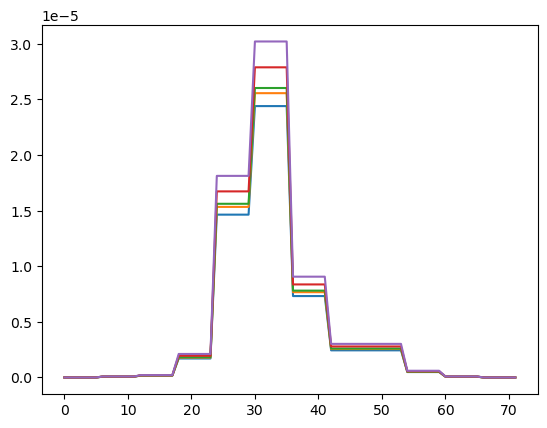

In [221]:
plt.plot(scaled_scenarios[1.05])
plt.plot(scaled_scenarios[1.1])
plt.plot(scaled_scenarios[1.12])
plt.plot(scaled_scenarios[1.2])
plt.plot(scaled_scenarios[1.3])

# To run in climcal

In [95]:
### Hourly data from climstore
xr_in = xr.open_mfdataset('/mnt/climstor/meteoswiss/Combiprecip/CPCH_hourly/CPC_00060_H_'+year+month+'*', concat_dim='REFERENCE_TS',combine='nested')
xr_in.y.attrs["units"] = "m"  # (optional) correct it
xr_in.x.attrs["units"] = "m"  # (optional) correct it
print(xr_in.y)
#assert min_x >= xr_in.x.min().values and max_x <= xr_in.x.max().values
#assert min_y >= xr_in.y.min().values and max_y <= xr_in.y.max().values


<xarray.DataArray 'y' (y: 640)> Size: 5kB
array([1479500., 1478500., 1477500., ...,  842500.,  841500.,  840500.])
Coordinates:
  * y        (y) float64 5kB 1.48e+06 1.478e+06 ... 8.415e+05 8.405e+05
Attributes:
    long_name:      y coordinate of projection
    standard_name:  projection_y_coordinate
    units:          m


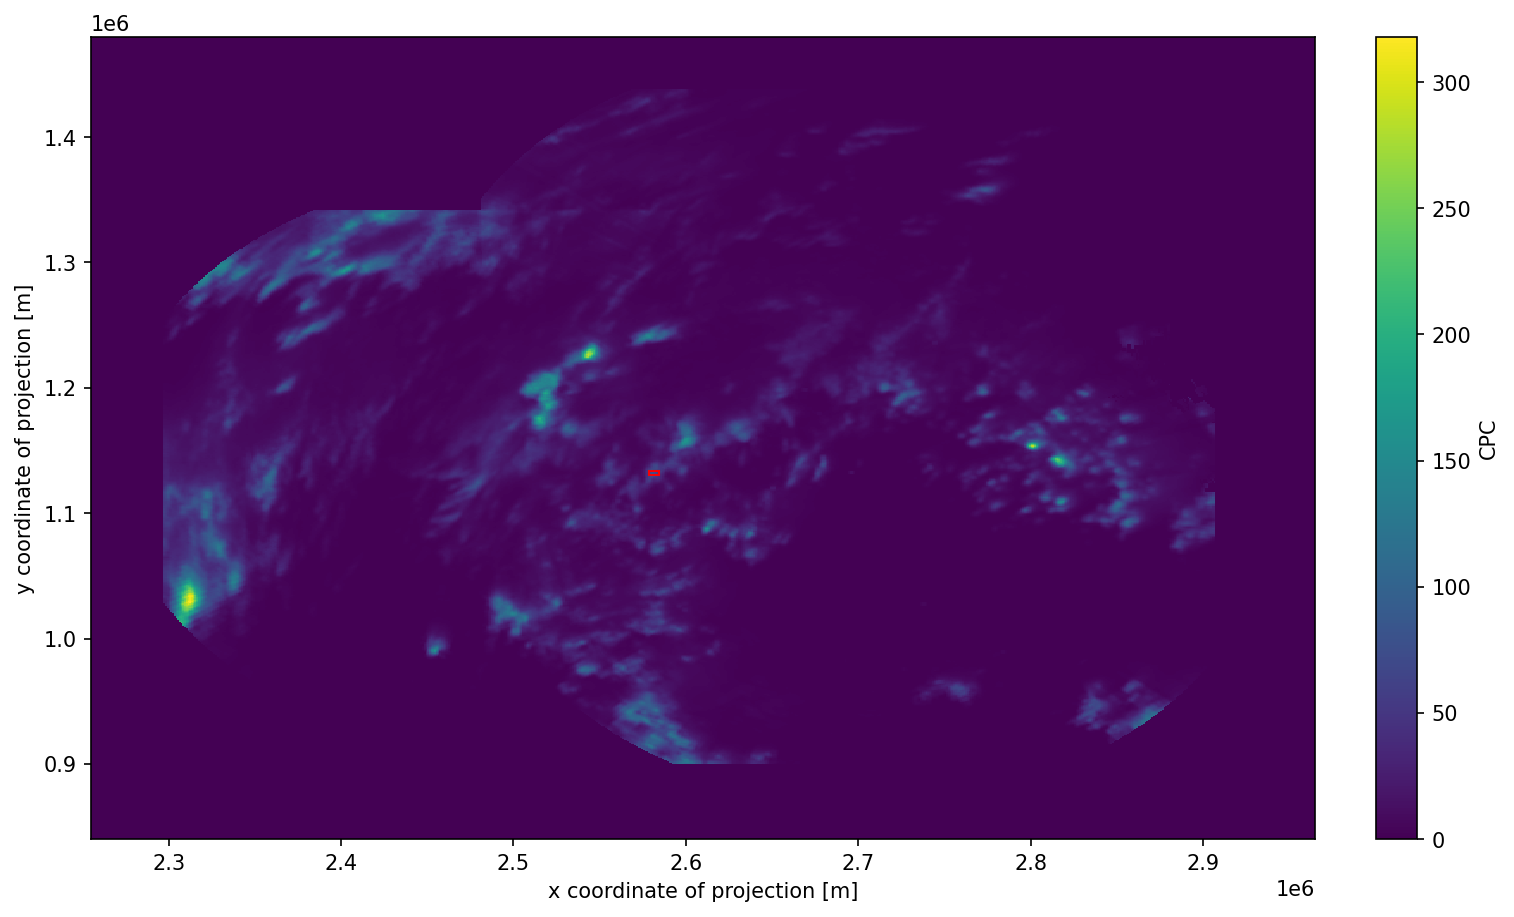

In [96]:
### mean of day of interest
plt.figure(figsize=(10,6),dpi=150,layout='constrained')
ax=plt.axes()
xr_in.CPC.sel(REFERENCE_TS=year+'-'+month+'-'+day).sum(axis=[0]).plot(ax=ax)
ax.add_patch(mpatches.Rectangle(xy=[min_x, min_y], width=width_size, height=height_size, \
        facecolor='none', alpha=0.95, edgecolor='r', linewidth=1, zorder=1))

<xarray.Dataset> Size: 75kB
Dimensions:       (REFERENCE_TS: 720, y: 4, x: 6)
Coordinates:
  * REFERENCE_TS  (REFERENCE_TS) datetime64[ns] 6kB 2005-06-01 ... 2005-06-30...
  * y             (y) float64 32B 1.134e+06 1.132e+06 1.132e+06 1.13e+06
  * x             (x) float64 48B 2.578e+06 2.58e+06 ... 2.582e+06 2.584e+06
Data variables:
    CPC           (REFERENCE_TS, y, x) float32 69kB dask.array<chunksize=(360, 4, 6), meta=np.ndarray>
Attributes:
    Conventions:      CF-1.6
    Source_Software:  FME


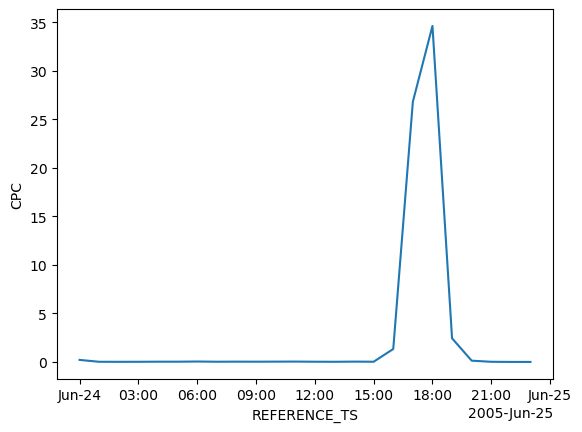

In [97]:
### select the domain of interest
region=xr_in.sel(y=slice(max_y,min_y), x=slice(min_x, max_x)) # inverse order for coordinate y
print(region)
### mean of the area
region.CPC.sel(REFERENCE_TS=year+'-'+month+'-'+day).mean(axis=[1,2]).plot()

<strong>5 minutes data</strong>

In [98]:
def open_and_add_time(filepath):
    # Example filename: CPC0517523200_00005.000.h5
    fname = os.path.basename(filepath)

    try:
        # Extract components
        year_short = int(fname[3:5])        # YY
        year = 2000 + year_short            # Adjust if needed
        julian_day = int(fname[5:8])        # DDD
        hour = int(fname[8:10])             # HH
        minute = int(fname[10:12])          # MM

        # Convert to datetime
        timestamp = pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=julian_day - 1, hours=hour, minutes=minute)
    except Exception as e:
        print(f"Failed to parse time from {fname}: {e}")
        return None

    # Open dataset from correct group
    ds = xr.open_dataset(filepath, engine="netcdf4", group="/dataset1/data1")

    # Add time dimension
    ds = ds.expand_dims(time=[timestamp])
    return ds

In [99]:
### Open files
### Original data is store per (julian) day in:
###/mnt/climstor/meteoswiss/Combiprecip/CPCH_5min/

In [100]:
#one file
#ds =xr.open_dataset("/home/edolores/CPC/CPC0517517003_00005.000.h5", engine="netcdf4", group="/dataset1/data1")

### Several files
pattern = "/home/edolores/CPC/CPC05175*_00005.000.h5"
files = sorted(glob.glob(pattern))

datasets = [open_and_add_time(f) for f in files if open_and_add_time(f) is not None]
merged_ds = xr.concat(datasets, dim="time")

print(merged_ds)

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 288, phony_dim_0: 640, phony_dim_1: 710)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2005-06-24 ... 2005-06-24T23:55:00
Dimensions without coordinates: phony_dim_0, phony_dim_1
Data variables:
    data     (time, phony_dim_0, phony_dim_1) float64 1GB nan nan ... nan nan


In [101]:
#Let's assign x,y coordinates from the hourly data:
# First, rename phony dims to match target names
merged_ds = merged_ds.rename({
    "phony_dim_1": "x",  # x is usually longitude/easting
    "phony_dim_0": "y"   # y is usually latitude/northing
})

merged_ds = merged_ds.assign_coords({
    "x": xr_in["x"],
    "y": xr_in["y"]
})

merged_ds["x"].attrs = xr_in["x"].attrs
merged_ds["y"].attrs = xr_in["y"].attrs

merged_ds = merged_ds.rename_vars({"data": "precip"})

print(merged_ds)#.data#.mean(axis=[1,2])#.plot()
#ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 288, y: 640, x: 710)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2005-06-24 ... 2005-06-24T23:55:00
  * x        (x) float64 6kB 2.256e+06 2.256e+06 ... 2.964e+06 2.964e+06
  * y        (y) float64 5kB 1.48e+06 1.478e+06 ... 8.415e+05 8.405e+05
Data variables:
    precip   (time, y, x) float64 1GB nan nan nan nan nan ... nan nan nan nan


In [102]:
### select region
region_5min=merged_ds.sel(y=slice(max_y,min_y), x=slice(min_x, max_x)) # inverse order for coordinate y
print(region_5min)

<xarray.Dataset> Size: 58kB
Dimensions:  (time: 288, y: 4, x: 6)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2005-06-24 ... 2005-06-24T23:55:00
  * x        (x) float64 48B 2.578e+06 2.58e+06 2.58e+06 ... 2.582e+06 2.584e+06
  * y        (y) float64 32B 1.134e+06 1.132e+06 1.132e+06 1.13e+06
Data variables:
    precip   (time, y, x) float64 55kB 0.0 0.0 0.0 0.01 ... 0.0 0.0 0.01 0.01


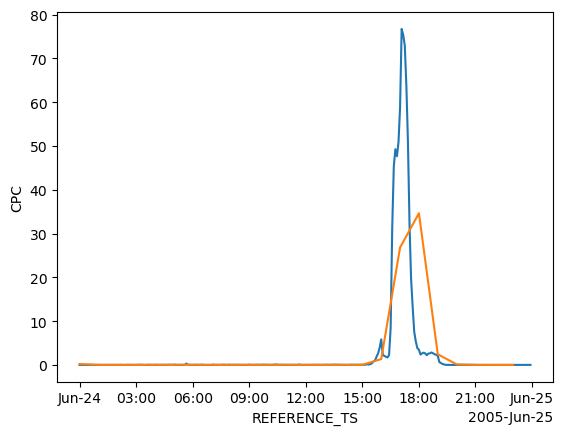

In [103]:
### compare the time serie of hourly and 5 minutes
region_5min.precip.mean(dim=["y","x"]).plot()
region.CPC.sel(REFERENCE_TS=year+'-'+month+'-'+day).mean(axis=[1,2]).plot()

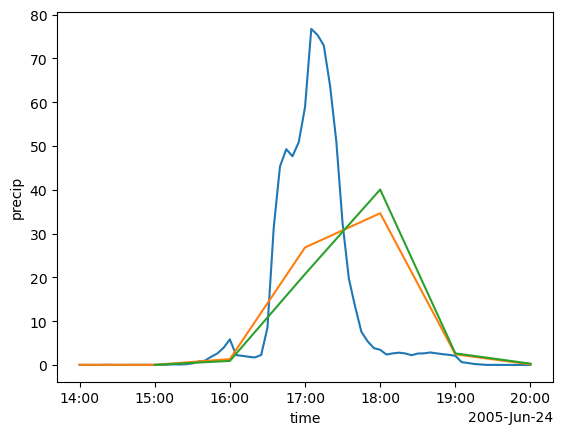

In [108]:
### From 14:00 to 20:00
region_5min.precip.sel(time=slice("2005-06-24T14:00:00","2005-06-24T20:00:00")).mean(dim=["y","x"]).plot(add_legend=True)
region.CPC.sel(REFERENCE_TS=slice("2005-06-24T14:00:00","2005-06-24T20:00:00")).mean(dim=["y","x"]).plot(add_legend=True)
ts_new.plot()

<strong>Save time serie</strong>

In [105]:
### only from 14:30 to 20:00
ts=region_5min.precip.sel(time=slice("2005-06-24T14:30:00","2005-06-24T20:00:00")).mean(dim=["y","x"])
# Convert to DataFrame (results in columns: ['precip'], index: time)
df = ts.to_dataframe().reset_index()  # Now columns: ['time', 'precip']
# Save to CSV
df.to_csv("cpc_region_timeseries_20050424_1430_2000.csv", index=False) 

<strong>Save as raster</strong>

In [106]:
# Example: single 5-min step at 14:30 UTC
raster = region_5min.sel(time="2005-06-24T14:30:00")["precip"]
raster = raster.rio.write_crs("EPSG:2056")
#raster.rio.to_raster("region_5min_20050624T1500_epsg2056.tif")

### save as raster [only from 14:30 to 20:00]
region_5min_event=region_5min.sel(time=slice("2005-06-24T14:30:00","2005-06-24T20:00:00"))
region_5min_event["precip"].rio.write_crs("EPSG:2056").rio.to_raster("cpc_region_5min_epsg2056_multiband.tif")

/home/edolores/.conda/envs/nextgems/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:514: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


In [107]:
### getting hourly data from the 5 minute data
ts_new=region_5min.precip.sel(time=slice("2005-06-24T14:00:00","2005-06-24T20:00:00")).mean(dim=["y","x"])
ts_new=ts_new.resample(time='h').mean().shift(time=1) 
ts_new
#region_5min.y

<xarray.DataArray 'precip' (time: 7)> Size: 56B
array([           nan, 1.73958333e-02, 9.15312500e-01, 2.07401736e+01,
       4.00502083e+01, 2.63177083e+00, 2.92500000e-01])
Coordinates:
  * time     (time) datetime64[ns] 56B 2005-06-24T14:00:00 ... 2005-06-24T20:...

<strong>Getting latitude and longitude information</strong>

In [8]:
'''
x1=obs_jja.x.values
y1=obs_jja.y.values

x=np.array(x1)
y=np.array(y1)
xv, yv = np.meshgrid(x,y)

transformer=Transformer.from_crs('epsg:2056','epsg:4326', always_xy=True)
lons,lats=transformer.transform(xv,yv)

## add new coordinates lontitude and latitude

data = obs_jja.assign_coords({
    'latitude':(['y','x'],lats),
    'longitude':(['y','x'],lons)
    })

# Extract lat,lon and time
time=data.REFERENCE_TS.values
obs_lon = data.longitude.values
obs_lat = data.latitude.values
obs_lat
'''

"\nx1=obs_jja.x.values\ny1=obs_jja.y.values\n\nx=np.array(x1)\ny=np.array(y1)\nxv, yv = np.meshgrid(x,y)\n\ntransformer=Transformer.from_crs('epsg:2056','epsg:4326', always_xy=True)\nlons,lats=transformer.transform(xv,yv)\n\n## add new coordinates lontitude and latitude\n\ndata = obs_jja.assign_coords({\n    'latitude':(['y','x'],lats),\n    'longitude':(['y','x'],lons)\n    })\n\n# Extract lat,lon and time\ntime=data.REFERENCE_TS.values\nobs_lon = data.longitude.values\nobs_lat = data.latitude.values\nobs_lat\n"